Computing Carnot Dv heatmap...
    row 0/500
    row 10/500
    row 20/500
    row 30/500
    row 40/500
    row 50/500
    row 60/500
    row 70/500
    row 80/500
    row 90/500
    row 100/500
    row 110/500
    row 120/500
    row 130/500
    row 140/500
    row 150/500
    row 160/500
    row 170/500
    row 180/500
    row 190/500
    row 200/500
    row 210/500
    row 220/500
    row 230/500
    row 240/500
    row 250/500
    row 260/500
    row 270/500
    row 280/500
    row 290/500
    row 300/500
    row 310/500
    row 320/500
    row 330/500
    row 340/500
    row 350/500
    row 360/500
    row 370/500
    row 380/500
    row 390/500
    row 400/500
    row 410/500
    row 420/500
    row 430/500
    row 440/500
    row 450/500
    row 460/500
    row 470/500
    row 480/500
    row 490/500


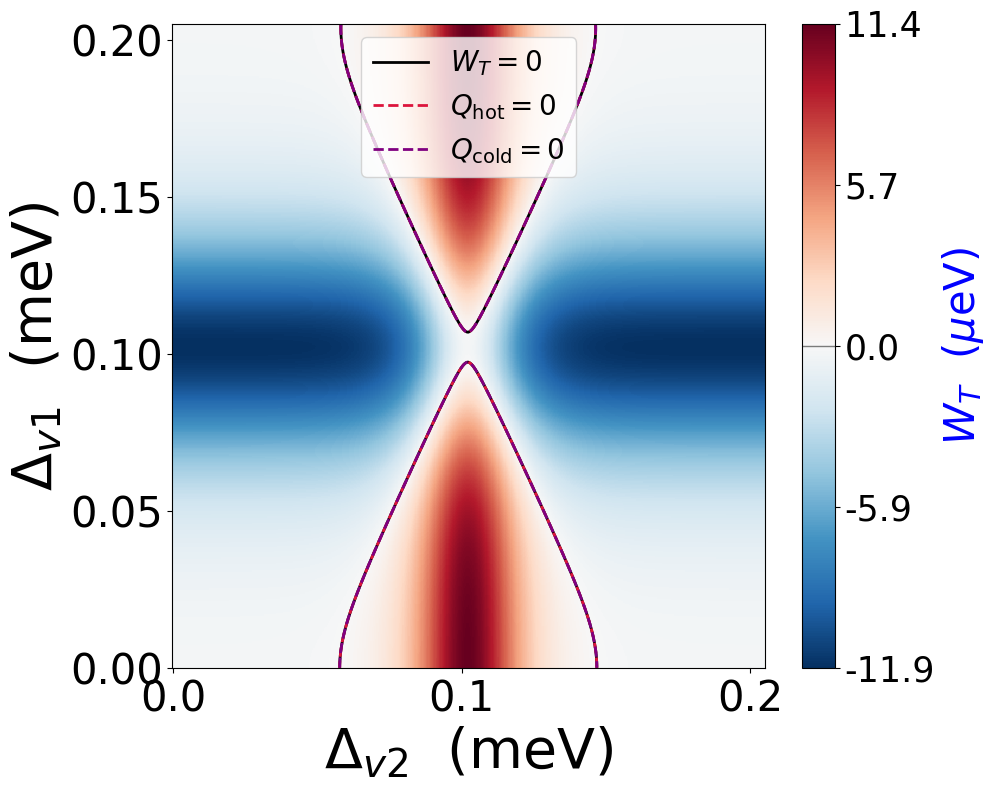

(array([0.        , 0.00041082, 0.00082164, 0.00123246, 0.00164329,
        0.00205411, 0.00246493, 0.00287575, 0.00328657, 0.00369739,
        0.00410822, 0.00451904, 0.00492986, 0.00534068, 0.0057515 ,
        0.00616232, 0.00657315, 0.00698397, 0.00739479, 0.00780561,
        0.00821643, 0.00862725, 0.00903808, 0.0094489 , 0.00985972,
        0.01027054, 0.01068136, 0.01109218, 0.01150301, 0.01191383,
        0.01232465, 0.01273547, 0.01314629, 0.01355711, 0.01396794,
        0.01437876, 0.01478958, 0.0152004 , 0.01561122, 0.01602204,
        0.01643287, 0.01684369, 0.01725451, 0.01766533, 0.01807615,
        0.01848697, 0.0188978 , 0.01930862, 0.01971944, 0.02013026,
        0.02054108, 0.0209519 , 0.02136273, 0.02177355, 0.02218437,
        0.02259519, 0.02300601, 0.02341683, 0.02382766, 0.02423848,
        0.0246493 , 0.02506012, 0.02547094, 0.02588176, 0.02629259,
        0.02670341, 0.02711423, 0.02752505, 0.02793587, 0.02834669,
        0.02875752, 0.02916834, 0.02957916, 0.02

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.lines import Line2D

kb = 8.617333e-2  # meV/K

# ── thermodynamic helpers (Dv-based) ─────────────────────────
def _get_energies_Dv(Dv_arr, energies, Dv):
    """Get energy branches at the closest Dv value."""
    idx = np.argmin(np.abs(Dv_arr - Dv))
    e   = energies[idx]
    return e[~np.isnan(e)]

def F_Dv(Dv_arr, energies, Dv, T):
    kbT = kb * T
    e   = _get_energies_Dv(Dv_arr, energies, Dv)
    x   = e / kbT
    log1pexp = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))
    return -kbT * np.sum(log1pexp)

def S_Dv(Dv_arr, energies, Dv, T):
    kbT = kb * T
    e   = _get_energies_Dv(Dv_arr, energies, Dv)
    x   = e / kbT
    log_term = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))
    occ_term = x / (np.exp(np.clip(x, -500, 500)) + 1)
    return kb * np.sum(log_term + occ_term)

def U_Dv(Dv_arr, energies, Dv, T):
    kbT = kb * T
    e   = _get_energies_Dv(Dv_arr, energies, Dv)
    f   = 1.0 / (np.exp(np.clip(e / kbT, -500, 500)) + 1.0)
    return np.sum(e * f)


# ── Carnot cycle over Dv ────────────────────────────────────────
def carnot_Dv(Dv_arr, energies, Dv1, Dv2, Tc, Th):
    """
    Quantum Carnot cycle with Dv as the work parameter.

    Stroke A→B  isothermal (hot):   (Dv1, Th) → (Dv2, Th)
    Stroke B→C  adiabatic:          (Dv2, Th) → (Dv2, Tc)
    Stroke C→D  isothermal (cold):  (Dv2, Tc) → (Dv1, Tc)
    Stroke D→A  adiabatic:          (Dv1, Tc) → (Dv1, Th)

    Entropy conditions:
        S_B = S_C  (adiabat B→C) - automatically satisfied since same Dv2
        S_D = S_A  (adiabat D→A) - automatically satisfied since same Dv1

    Qhot = Th (S_B - S_A) = Th (S(Dv2, Th) - S(Dv1, Th))
    Qcold = Tc (S_D - S_C) = Tc (S(Dv1, Tc) - S(Dv2, Tc))
    W = Qhot + Qcold
    """
    # Entropy at each state
    S_A = S_Dv(Dv_arr, energies, Dv1, Th)
    S_C = S_Dv(Dv_arr, energies, Dv2, Tc)

    S_B =S_C
    S_D =S_A


    # Heat exchanges
    Qhot = Th * (S_B - S_A)      # Heat absorbed from hot reservoir
    Qcold = Tc * (S_D - S_C)     # Heat released to cold reservoir (negative)

    # Total work (First law: W = Qhot + Qcold)
    WT = Qhot + Qcold

    # Optional: Verify entropy conditions (should be automatically satisfied)
    # For a Carnot cycle: S_B = S_C and S_D = S_A
    res_BC = abs(S_B - S_C)
    res_DA = abs(S_D - S_A)
    if res_BC > 1e-6 or res_DA > 1e-6:
        print(f"  WARNING: Entropy conditions not satisfied: ΔS_BC={res_BC:.2e}, ΔS_DA={res_DA:.2e}")

    return Qhot, Qcold, WT, S_A, S_B, S_C, S_D


# ── sweep Dv2 ─────────────────────────────────────────────────
def carnot_sweep_Dv(Dv_arr, energies, Dv1, Tc, Th, save=False):
    """Sweep Dv2 over all values and plot Qhot, Qcold, WT."""
    n = len(Dv_arr)
    WT_arr     = np.zeros(n)
    Qhot_arr   = np.zeros(n)
    Qcold_arr  = np.zeros(n)

    for i, Dv2 in enumerate(Dv_arr):
        Qhot, Qcold, WT, _, _, _, _ = carnot_Dv(
            Dv_arr, energies, Dv1, Dv2, Tc, Th)
        WT_arr[i]     = WT
        Qhot_arr[i]   = Qhot
        Qcold_arr[i]  = Qcold

    # plot: Qhot, Qcold, WT
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for ax, arr, label, color in [
        (axes[0], Qhot_arr,  r"$Q_\mathrm{hot}$  (meV)",  "crimson"),
        (axes[1], Qcold_arr, r"$Q_\mathrm{cold}$ (meV)",  "royalblue"),
        (axes[2], WT_arr,    r"$W_T$  (meV)",              "seagreen"),
    ]:
        ax.plot(Dv_arr, arr, color=color, lw=2)
        ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.5)
        ax.set_ylabel(label, fontsize=20)
        ax.tick_params(axis='both', labelsize=20)
        ax.grid(alpha=0.2)

    axes[2].set_xlabel(r"$\Delta_v^{(2)}$  (meV)", fontsize=20)
    axes[2].tick_params(axis='both', labelsize=20)
    #fig.suptitle(fr"Quantum Carnot Cycle  —  $\Delta_v^{{(1)}}$={Dv1:.3f} meV, $T_c$={Tc} K, $T_h$={Th} K",
    #             fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig("carnot_sweep_Dv.png", dpi=150, bbox_inches="tight")
        print("Saved carnot_sweep_Dv.png")
    plt.show()

    return Dv_arr, Qhot_arr, Qcold_arr, WT_arr


# ── Carnot heatmap: Dv1 vs Dv2, color = WT ─────────────────────
def carnot_heatmap_Dv(Dv_arr, energies, Tc, Th, n=60, save=False):
    """Dv1 vs Dv2 heatmap of WT with contour lines."""
    Dv_grid   = np.linspace(Dv_arr.min(), Dv_arr.max(), n)
    WT_map    = np.full((n, n), np.nan)
    Qhot_map  = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)

    print("Computing Carnot Dv heatmap...")
    for i, Dv1 in enumerate(Dv_grid):
        if i % 10 == 0:
            print(f"    row {i}/{n}")
        for j, Dv2 in enumerate(Dv_grid):
            Qhot, Qcold, WT, _, _, _, _ = carnot_Dv(Dv_arr, energies, Dv1, Dv2, Tc, Th)
            WT_map[i, j]    = WT*1000
            Qhot_map[i, j]  = Qhot
            Qcold_map[i, j] = Qcold

    # Get min and max values for the colorbar (excluding NaN)
    vmin = np.nanmin(WT_map)
    vmax = np.nanmax(WT_map)

    # Use TwoSlopeNorm to put white at zero
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(Dv_grid, Dv_grid, WT_map,
                       cmap="RdBu_r", norm=norm, shading="auto")

    # Add colorbar with appropriate ticks
    cbar = plt.colorbar(im, ax=ax, label=r"$W_T$  ($\mu$eV)")
    cbar.ax.set_ylabel(r'$W_T$  ($\mu$eV)', fontsize=30,color='blue')
    cbar.ax.tick_params(labelsize=25)

    # Set colorbar ticks to include min and max values
    cbar_ticks = [vmin, 0, vmax]
    if vmin < 0 and vmax > 0:
        mid_neg = vmin / 2 if vmin < 0 else None
        mid_pos = vmax / 2 if vmax > 0 else None
        if mid_neg is not None and mid_neg > vmin:
            cbar_ticks.append(mid_neg)
        if mid_pos is not None and mid_pos < vmax:
            cbar_ticks.append(mid_pos)
    cbar_ticks = sorted(set(cbar_ticks))
    cbar.set_ticks(cbar_ticks)
    cbar.ax.set_yticklabels([f'{tick:.1f}' for tick in cbar_ticks])

    # Optional: Add a white line at zero to emphasize it
    cbar.ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)

    # For axis ticks
    ax.tick_params(axis='both', labelsize=30)

    cs_kw = dict(linewidths=2)
    ax.contour(Dv_grid, Dv_grid, WT_map, levels=[0], colors="black", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qhot_map, levels=[0], colors="crimson",
               linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qcold_map, levels=[0], colors="purple",
               linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0],[0], color='black',   lw=2, ls='-',  label=r'$W_T=0$'),
        Line2D([0],[0], color='crimson', lw=2, ls='--', label=r'$Q_\mathrm{hot}=0$'),
        Line2D([0],[0], color='purple',  lw=2, ls='--', label=r'$Q_\mathrm{cold}=0$'),
    ], fontsize=20, loc='upper center')

    ax.set_xlabel(r"$\Delta_{v2}$  (meV)", fontsize=40)
    ax.set_ylabel(r"$\Delta_{v1}$  (meV)", fontsize=40)
    plt.tight_layout()
    plt.savefig("3Fig7a.png", dpi=150, bbox_inches="tight")

    plt.show()
    return Dv_grid, WT_map


# ── run ───────────────────────────────────────────────────────
Tc = 0.05
Th = 0.10

data     = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)
Dv_arr   = data[:, 0]
energies = data[:, 1:9]

# Sweep
#Dv_out, Qhot, Qcold, WT = carnot_sweep_Dv(
#    Dv_arr, energies, Dv1=0.103218, Tc=Tc, Th=Th, save=False)

# WT heatmap
carnot_heatmap_Dv(Dv_arr, energies, Tc=Tc, Th=Th, n=500, save=False)

Computing Carnot heatmap...
  row 0/500
  row 10/500
  row 20/500
  row 30/500
  row 40/500
  row 50/500
  row 60/500
  row 70/500
  row 80/500
  row 90/500
  row 100/500
  row 110/500
  row 120/500
  row 130/500
  row 140/500
  row 150/500
  row 160/500
  row 170/500
  row 180/500
  row 190/500
  row 200/500
  row 210/500
  row 220/500
  row 230/500
  row 240/500
  row 250/500
  row 260/500
  row 270/500
  row 280/500
  row 290/500
  row 300/500
  row 310/500
  row 320/500
  row 330/500
  row 340/500
  row 350/500
  row 360/500
  row 370/500
  row 380/500
  row 390/500
  row 400/500
  row 410/500
  row 420/500
  row 430/500
  row 440/500
  row 450/500
  row 460/500
  row 470/500
  row 480/500
  row 490/500


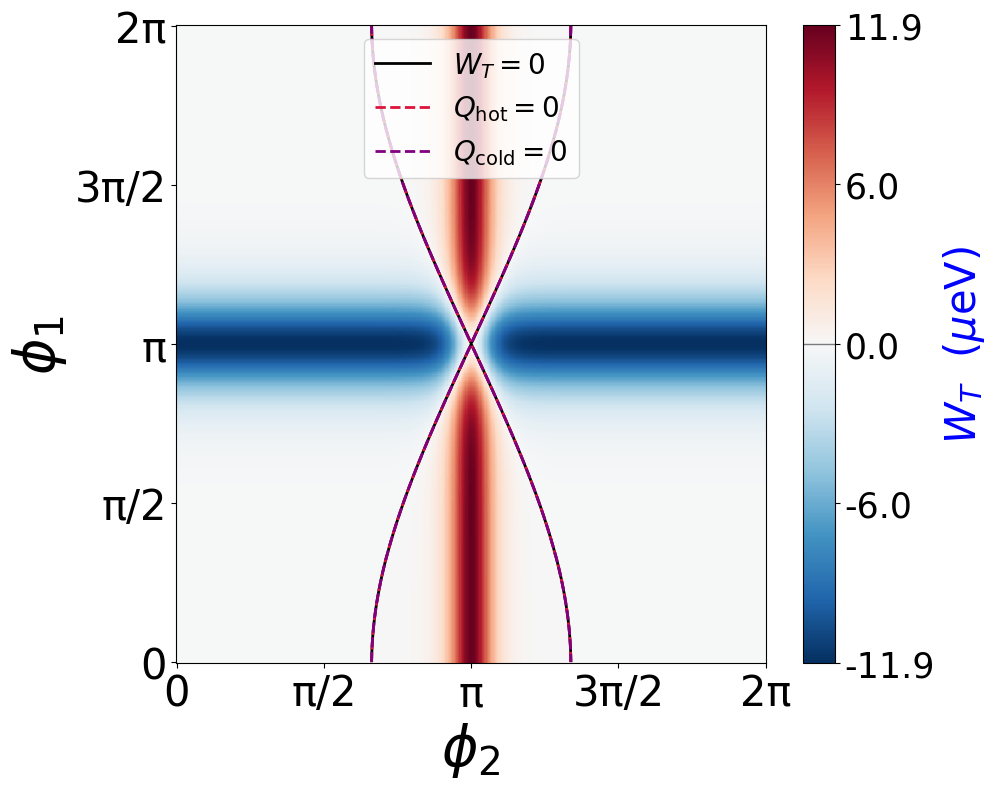

(array([0.        , 0.01259155, 0.02518311, 0.03777466, 0.05036621,
        0.06295777, 0.07554932, 0.08814088, 0.10073243, 0.11332398,
        0.12591554, 0.13850709, 0.15109864, 0.1636902 , 0.17628175,
        0.18887331, 0.20146486, 0.21405641, 0.22664797, 0.23923952,
        0.25183107, 0.26442263, 0.27701418, 0.28960574, 0.30219729,
        0.31478884, 0.3273804 , 0.33997195, 0.3525635 , 0.36515506,
        0.37774661, 0.39033817, 0.40292972, 0.41552127, 0.42811283,
        0.44070438, 0.45329593, 0.46588749, 0.47847904, 0.4910706 ,
        0.50366215, 0.5162537 , 0.52884526, 0.54143681, 0.55402836,
        0.56661992, 0.57921147, 0.59180302, 0.60439458, 0.61698613,
        0.62957769, 0.64216924, 0.65476079, 0.66735235, 0.6799439 ,
        0.69253545, 0.70512701, 0.71771856, 0.73031012, 0.74290167,
        0.75549322, 0.76808478, 0.78067633, 0.79326788, 0.80585944,
        0.81845099, 0.83104255, 0.8436341 , 0.85622565, 0.86881721,
        0.88140876, 0.89400031, 0.90659187, 0.91

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.lines import Line2D

kb = 8.617333e-2  # meV/K

# ── thermodynamic helpers ─────────────────────────────────────
def _get_energies(data, data_tm, phi):
    """Get all energies (both valleys) for a given phi."""
    phi_arr = data[:, 0]
    idx = np.argmin(np.abs(phi_arr - phi))
    e1 = data[idx, 1:];    e1 = e1[~np.isnan(e1)]
    e2 = data_tm[idx, 1:]; e2 = e2[~np.isnan(e2)]
    return np.concatenate([e1, e2])  # 8 total energies

def free_energy_phi(data, data_tm, phi, T):
    """
    Free energy: F = -kbT * sum_n ln(1 + exp(-E_n/kbT))
    """
    kbT = kb * T
    e = _get_energies(data, data_tm, phi)
    return -kbT * np.sum(np.log(1 + np.exp(-e / kbT)))

def fermi(e, T):
    """Fermi-Dirac occupation number."""
    if T < 1e-12:  # Effectively zero temperature
        return 1.0 if e < 0 else 0.0
    return 1.0 / (1.0 + np.exp(e / (kb * T)))

def entropy_phi(data, data_tm, phi, T):
    """
    Entropy directly from occupation numbers:
    S = -kb * sum_n [f_n ln f_n + (1-f_n) ln(1-f_n)]
    """
    energies = _get_energies(data, data_tm, phi)

    S_val = 0.0
    for e in energies:
        f = fermi(e, T)
        if 0 < f < 1:
            S_val += -f * np.log(f) - (1-f) * np.log(1-f)
        # f=0 or f=1 contribute 0

    return kb * S_val  # Multiply by kb for proper units

def internal_energy_phi(data, data_tm, phi, T):
    """
    Internal energy directly from occupation numbers:
    U = sum_n f_n * E_n
    """
    energies = _get_energies(data, data_tm, phi)
    return np.sum([fermi(e, T) * e for e in energies])


# ── Carnot cycle (phi-based) ────────────────────────────────────────
def carnot_phi(data, data_tm, phi1, phi2, Tc, Th):
    """
    Quantum Carnot cycle with phi as the work parameter.

    Stroke A→B  isothermal (hot):   (phi1, Th) → (phi2, Th)
    Stroke B→C  adiabatic:          (phi2, Th) → (phi2, Tc)
    Stroke C→D  isothermal (cold):  (phi2, Tc) → (phi1, Tc)
    Stroke D→A  adiabatic:          (phi1, Tc) → (phi1, Th)

    Entropy conditions:
        S_B = S_C  (adiabat B→C) - automatically satisfied since same phi2
        S_D = S_A  (adiabat D→A) - automatically satisfied since same phi1

    Qhot = Th (S_B - S_A) = Th (S(phi2, Th) - S(phi1, Th))
    Qcold = Tc (S_D - S_C) = Tc (S(phi1, Tc) - S(phi2, Tc))
    W = Qhot + Qcold

    Returns
    -------
    Qhot, Qcold, WT, S_A, S_B, S_C, S_D
    """
    # Entropy at each state
    S_A = entropy_phi(data, data_tm, phi1, Th)
    S_C = entropy_phi(data, data_tm, phi2, Tc)
    S_B = S_C
    S_D = S_A

    # Heat exchanges
    Qhot = Th * (S_B - S_A)      # Heat absorbed from hot reservoir
    Qcold = Tc * (S_D - S_C)     # Heat released to cold reservoir (negative)

    # Total work (First law: W = Qhot + Qcold)
    WT = Qhot + Qcold

    # Verify entropy conditions (should be automatically satisfied)
    res_BC = abs(S_B - S_C)
    res_DA = abs(S_D - S_A)
    if res_BC > 1e-6 or res_DA > 1e-6:
        print(f"  WARNING: Entropy conditions not satisfied: ΔS_BC={res_BC:.2e}, ΔS_DA={res_DA:.2e}")

    return Qhot, Qcold, WT, S_A, S_B, S_C, S_D


# ── sweep phi2 ────────────────────────────────────────────────
def carnot_sweep_phi(data, data_tm, phi1, Tc, Th, n_phi2=600, save=False):
    """Sweep phi2 over [0, 2pi] and plot Qhot, Qcold, WT."""
    phi2_arr   = np.linspace(0, 2*np.pi, n_phi2)
    WT_arr     = np.zeros(n_phi2)
    Qhot_arr   = np.zeros(n_phi2)
    Qcold_arr  = np.zeros(n_phi2)

    print("Computing Carnot phi sweep...")
    for i, phi2 in enumerate(phi2_arr):
        if i % 100 == 0:
            print(f"  step {i}/{n_phi2} (phi2 = {phi2:.3f})")
        Qhot, Qcold, WT, _, _, _, _ = carnot_phi(
            data, data_tm, phi1, phi2, Tc, Th)
        WT_arr[i]     = WT
        Qhot_arr[i]   = Qhot
        Qcold_arr[i]  = Qcold

    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    xlbls  = ["0", "π/2", "π", "3π/2", "2π"]

    # ── plot: Qhot, Qcold, WT ──────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for ax, arr, label, color in [
        (axes[0], Qhot_arr,  r"$Q_\mathrm{hot}$  (meV)",  "crimson"),
        (axes[1], Qcold_arr, r"$Q_\mathrm{cold}$ (meV)",  "royalblue"),
        (axes[2], WT_arr,    r"$W_T$  (meV)",              "seagreen"),
    ]:
        ax.plot(phi2_arr, arr, color=color, lw=2)
        ax.axhline(0, color="gray", lw=1, ls="--", alpha=0.5)
        ax.set_ylabel(label, fontsize=20)
        ax.tick_params(axis='both', labelsize=20)
        ax.grid(alpha=0.2)

    axes[2].set_xlabel(r"$\phi_2$", fontsize=20)
    axes[2].set_xticks(xticks)
    axes[2].set_xticklabels(xlbls)
    axes[2].tick_params(axis='both', labelsize=20)
    #fig.suptitle(fr"Quantum Carnot Cycle  —  $\phi_1$={phi1:.3f}, $T_c$={Tc} K, $T_h$={Th} K",
    #             fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig("carnot_sweep_phi.png", dpi=150, bbox_inches="tight")
        print("Saved carnot_sweep_phi.png")
    plt.show()

    return phi2_arr, Qhot_arr, Qcold_arr, WT_arr


# ── heatmap ───────────────────────────────────────────────────
def carnot_heatmap_phi(data, data_tm, Tc, Th, n=80, save=False):
    """phi1 vs phi2 heatmap of WT with regime boundary contours for Carnot cycle."""
    phi_grid  = np.linspace(0, 2*np.pi, n)
    WT_map    = np.full((n, n), np.nan)
    Qhot_map  = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)

    print("Computing Carnot heatmap...")
    for i, phi1 in enumerate(phi_grid):
        if i % 10 == 0:
            print(f"  row {i}/{n}")
        for j, phi2 in enumerate(phi_grid):
            Qhot, Qcold, WT, _, _, _, _ = carnot_phi(
                data, data_tm, phi1, phi2, Tc, Th)
            Qhot_map[i, j]  = Qhot
            Qcold_map[i, j] = Qcold
            WT_map[i, j]    = WT*1000

    # Get min and max values for the colorbar (excluding NaN)
    vmin = np.nanmin(WT_map)
    vmax = np.nanmax(WT_map)

    # Use TwoSlopeNorm to put white at zero
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(phi_grid, phi_grid, WT_map,
                       cmap="RdBu_r", norm=norm, shading="auto")

    # Add colorbar with appropriate ticks
    cbar = plt.colorbar(im, ax=ax, label=r"$W_T$  ($\mu$eV)")
    cbar.ax.set_ylabel(r'$W_T$  ($\mu$eV)', fontsize=30,color='blue')  # Increase label size
    cbar.ax.tick_params(labelsize=25)  # Increase tick label size

    # Set colorbar ticks to include min and max values
    cbar_ticks = [vmin, 0, vmax]
    # Add some intermediate ticks for better readability
    if vmin < 0 and vmax > 0:
        # Add one intermediate negative and positive tick
        mid_neg = vmin / 2 if vmin < 0 else None
        mid_pos = vmax / 2 if vmax > 0 else None
        if mid_neg is not None and mid_neg > vmin:
            cbar_ticks.append(mid_neg)
        if mid_pos is not None and mid_pos < vmax:
            cbar_ticks.append(mid_pos)
    cbar_ticks = sorted(set(cbar_ticks))  # Remove duplicates and sort
    cbar.set_ticks(cbar_ticks)
    # Format tick labels with appropriate precision
    cbar.ax.set_yticklabels([f'{tick:.1f}' for tick in cbar_ticks])

    # Optional: Add a white line at zero to emphasize it
    cbar.ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)

    # For axis ticks
    ax.tick_params(axis='both', labelsize=30)  # Increase axis tick label size

    cs_kw = dict(linewidths=2)
    ax.contour(phi_grid, phi_grid, WT_map,    levels=[0], colors="black",   **cs_kw)
    ax.contour(phi_grid, phi_grid, Qhot_map,  levels=[0], colors="crimson",
               linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qcold_map, levels=[0], colors="purple",
               linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0],[0], color='black',   lw=2, ls='-',  label=r'$W_T=0$'),
        Line2D([0],[0], color='crimson', lw=2, ls='--', label=r'$Q_\mathrm{hot}=0$'),
        Line2D([0],[0], color='purple',  lw=2, ls='--', label=r'$Q_\mathrm{cold}=0$'),
    ], fontsize=20, loc='upper center')

    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tlbls = ["0", "π/2", "π", "3π/2", "2π"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tlbls)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tlbls)
    ax.set_xlabel(r"$\phi_2$", fontsize=40)
    ax.set_ylabel(r"$\phi_1$", fontsize=40)
    #ax.set_title(fr"Carnot $W_T(\phi_1,\phi_2)$  —  $T_c={Tc}$ K, $T_h={Th}$ K", fontsize=13)
    plt.tight_layout()

    plt.savefig("3Fig7b.png", dpi=150, bbox_inches="tight")

    plt.show()
    return phi_grid, WT_map


# ── run ───────────────────────────────────────────────────────
# Example usage (commented out):
#data_p = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
#data_m = np.loadtxt("ABS_MATBG_taum_Dv00.dat")

data_p = np.loadtxt("ABS_AABLG_taup_Dv00.dat")
data_m = np.loadtxt("ABS_AABLG_taum_Dv00.dat")

Tc = 0.05
Th = 0.10
phi1 = 0
#
# # Sweep
#phi2_arr, Qhot, Qcold, WT = carnot_sweep_phi(data_p, data_m, phi1, Tc=Tc, Th=Th, save=False)
#
# # Heatmap
carnot_heatmap_phi(data_p, data_m, Tc=Tc, Th=Th, n=500, save=False)